Import the odmlib modules needed to read a define.xml and convert the metadata to dataset-json datasets

In [1]:
# import os
import odmlib.define_loader as DL
import odmlib.loader as LD
from odmlib.dataset_json_1_1.define_flattener import DefineFlattener
from odmlib.dataset_json_1_1.define_builder import DefineBuilder

Load the definev21-SDTM.xml Define-XML file into obmlib

In [2]:
loader = LD.ODMLoader(DL.XMLDefineLoader(model_package='define_2_1'))
loader.open_odm_document('data/defineV21-SDTM.xml')
odm = loader.root()

Show the StudyName from the loaded Define-XML file

In [3]:
print(odm.Study.GlobalVariables.StudyName)

CDISC01_1


Flatten the Define-XML file metadata into a set of datasets and print out the dataset names as well as the columns for the datasets dataset.

In [4]:
flattener = DefineFlattener(odm)
datasets = flattener.flatten_all()
print(f"Datasets: {datasets.keys()}")
print("Columns in the datasets dataset:")
for col in datasets['datasets'].columns:
    print(col.name)

Datasets: dict_keys(['study', 'standards', 'datasets', 'variables', 'value_level', 'where_clauses', 'methods', 'comments', 'documents', 'codelists', 'codelist_terms', 'aliases', 'origins'])
Columns in the datasets dataset:
OID
Name
Repeating
IsReferenceData
SASDatasetName
Domain
Purpose
Structure
ArchiveLocationID
CommentOID
IsNonStandard
StandardOID
HasNoData
DescriptionText
ClassName
SubClassName
leafID
leafHref
leafTitle


Print the dataset names from both the Dataset-JSON metadata and the Define-XML metadata.

In [5]:
rows = datasets["datasets"].rows
dsj_names = [ds[1] for ds in datasets["datasets"].rows]
igd_names = [ig.Name for ig in odm.Study.MetaDataVersion.ItemGroupDef]
zipped_datasets = list(zip(igd_names, dsj_names))
print(zipped_datasets)

[('TS', 'TS'), ('DI', 'DI'), ('DM', 'DM'), ('EC', 'EC'), ('EX', 'EX'), ('LB', 'LB'), ('VS', 'VS'), ('XS', 'XS'), ('XX', 'XX'), ('SUPPDM', 'SUPPDM'), ('SUPPVS', 'SUPPVS')]


Compare the metadata in the variables dataset to the same metadata in the Define-XML

Write out the datasets to files. Each dataset file could represent a worksheet in a Define-XML metadata spreadsheet, and indeed coule be converted to such a spreadsheet for viewing. I prefer to use one of the Dataset-JSON viewers to review this metadata, such as the VDE Dataset Viewer.

In [6]:
import tempfile
paths = flattener.write_all(tempfile.mkdtemp())
for p in paths:
    print(p)

/tmp/tmpgbhw9xhw/study.json
/tmp/tmpgbhw9xhw/standards.json
/tmp/tmpgbhw9xhw/datasets.json
/tmp/tmpgbhw9xhw/variables.json
/tmp/tmpgbhw9xhw/value_level.json
/tmp/tmpgbhw9xhw/where_clauses.json
/tmp/tmpgbhw9xhw/methods.json
/tmp/tmpgbhw9xhw/comments.json
/tmp/tmpgbhw9xhw/documents.json
/tmp/tmpgbhw9xhw/codelists.json
/tmp/tmpgbhw9xhw/codelist_terms.json
/tmp/tmpgbhw9xhw/aliases.json
/tmp/tmpgbhw9xhw/origins.json


Here's an image of the Dataset-JSON datasets.json file using the VDE Dataset Viewer:

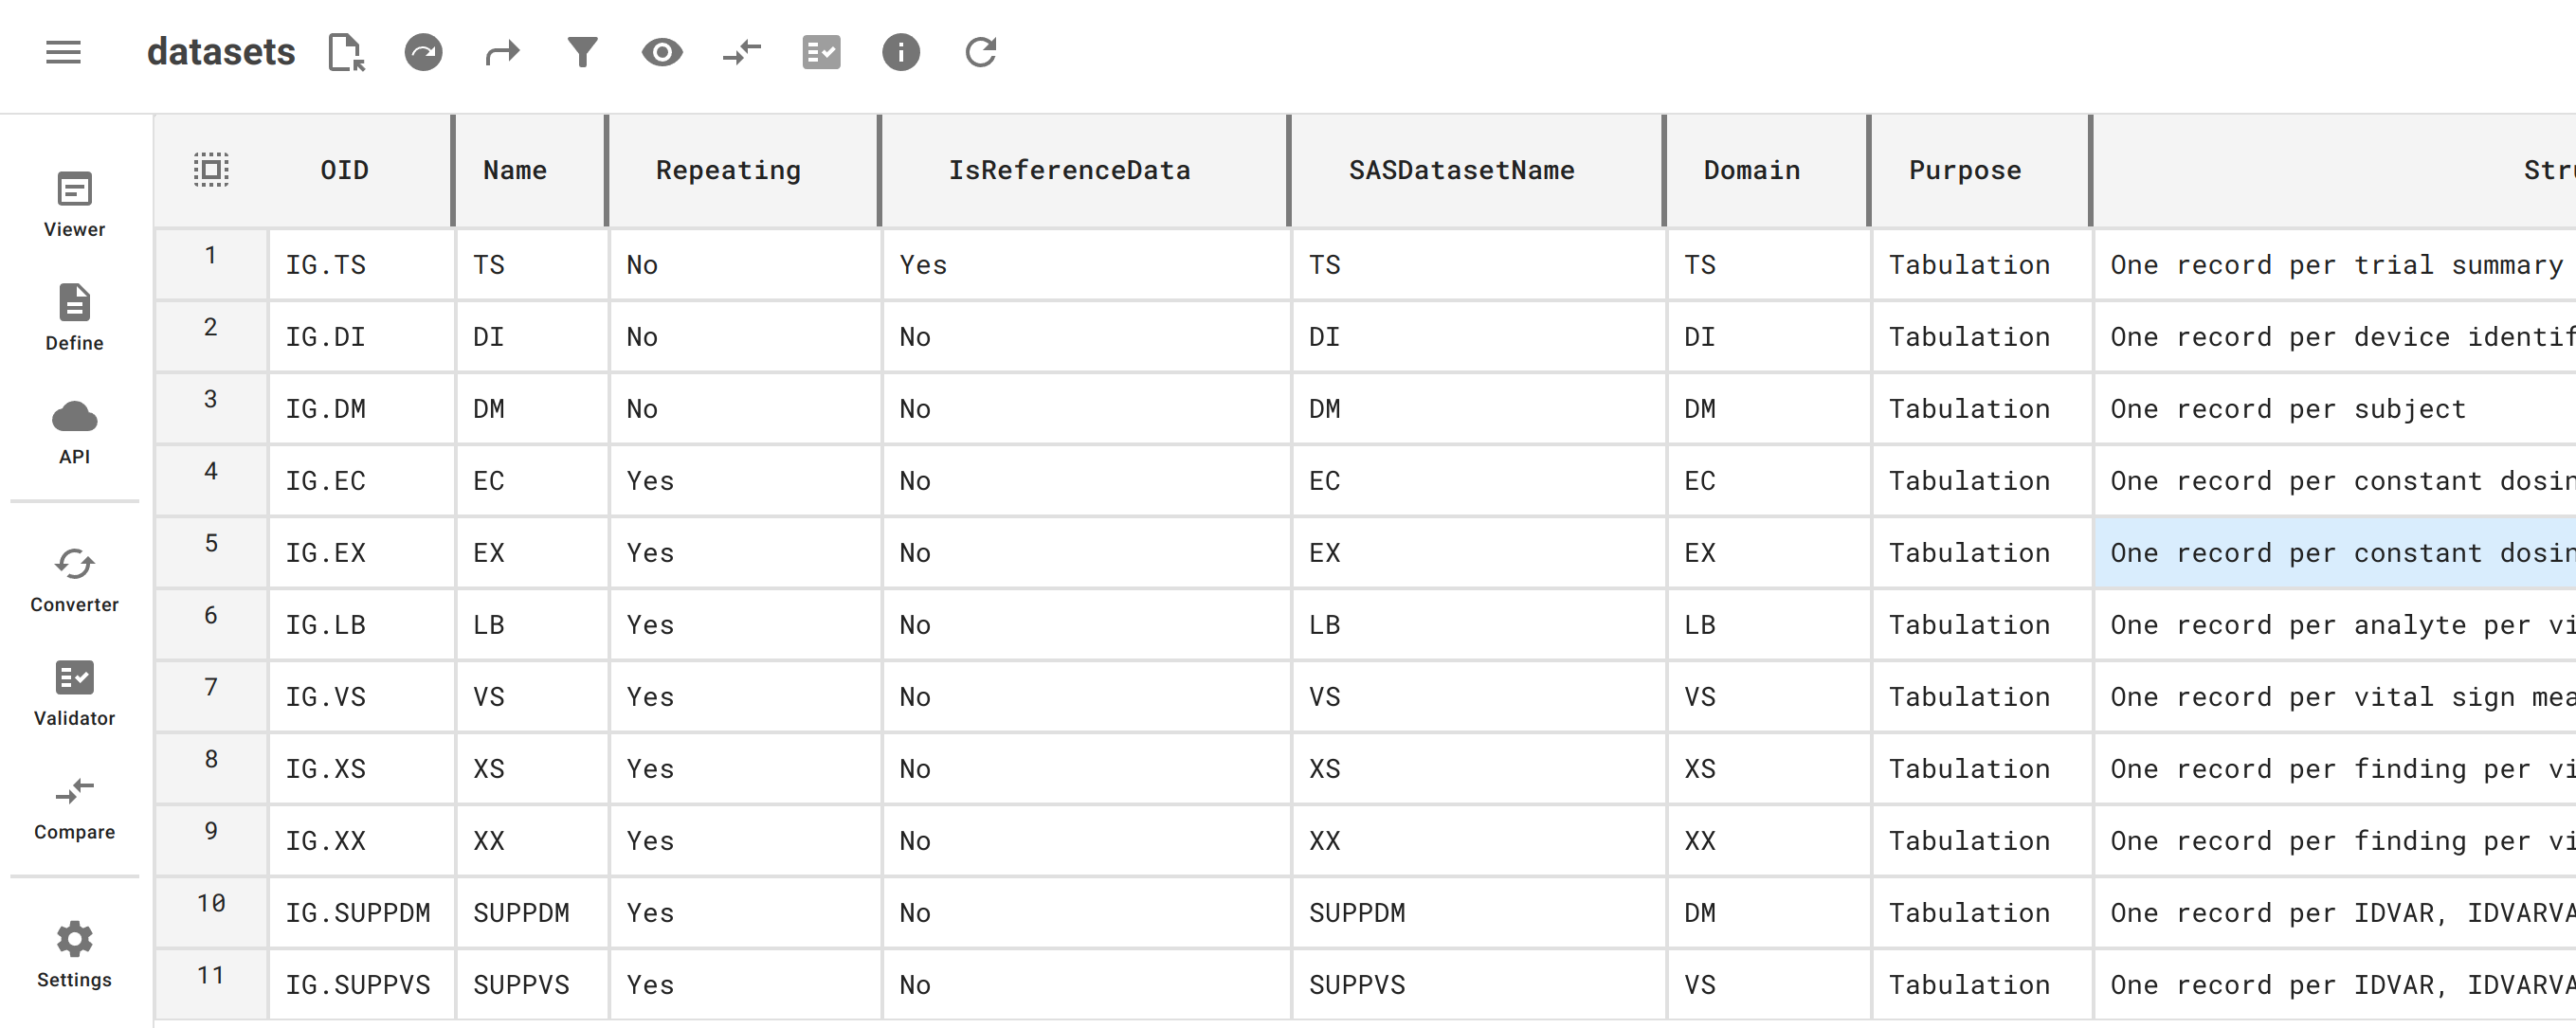

Now, let's roundtrip this and generate the Define-XML from the datasets.

In [7]:
rebuilt = DefineBuilder(datasets).build()
print(f"\nRebuilt ODM:")
print(f"  FileOID: {rebuilt.FileOID}")
print(f"  Study OID: {rebuilt.Study.OID}")
mdv = rebuilt.Study.MetaDataVersion
print(f"  ItemGroupDefs: {len(mdv.ItemGroupDef)}")
print(f"  ItemDefs: {len(mdv.ItemDef)}")
print(f"  CodeLists: {len(mdv.CodeList)}")
print(f"  MethodDefs: {len(mdv.MethodDef)}")



Rebuilt ODM:
  FileOID: www.cdisc.org/StudyCDISC01_1/1/Define-XML_2.1.0
  Study OID: STDY.www.cdisc.org.CDISC01_1
  ItemGroupDefs: 11
  ItemDefs: 179
  CodeLists: 40
  MethodDefs: 33


Next let's write the Define-XML to a file

In [8]:
import os
define_filename = os.path.join(tempfile.mkdtemp(), "define-rebuilt.xml")
rebuilt.write_xml(define_filename)
print(f"Define-XML written to {define_filename}")

Define-XML written to /tmp/tmpz_1g84ts/define-rebuilt.xml


After writing the rebuilt Define-XML to a file, let's schema validate it to ensure the roundtripping worked.

In [9]:
from odmlib import odm_parser as P
from odmlib.exceptions import OdmlibValidationError

validator = P.ODMSchemaValidator(standard="define", version="2.1")
try:
    validator.validate_file(define_filename)
    print("define-XML schema validation completed successfully...")
except OdmlibValidationError as ve:
    print(f"schema validation errors: {ve}")

define-XML schema validation completed successfully...
